# 02. How to Tell Who Won

**The question.** Before this lab trains a single model, it has to be able to say — with a
straight face — that one entity-resolution output is *better* than another. That sounds
administrative. It is not. Three separate choices silently decide most published ER
comparisons before any system runs: **which metric** scores an output (pairwise F1? B-cubed?
an edit distance between partitions?), **which operating point** each system is scored at
(its own best-F1 sweet spot? a fixed precision? an explicit error-cost?), and **which
resampling unit** the uncertainty interval treats as independent (pairs? records? entities?).
If any of those three can flip a ranking on realistic outputs, then a protocol that leaves
them unstated is not a measurement — it is a lever.

**What this notebook settles.** The lab's metrology, demonstrated rather than asserted, as
three pre-registered experiments on real system outputs built live in this run:
**MET-01** — do pairwise and entity-level metrics rank the same four outputs differently?
(They should, per Menestrina et al. 2010; we measure it, including a *constructed*
one-bad-merge output, labeled as constructed everywhere.)
**MET-02** — does the per-method best-F1 comparison reverse rankings against the lab's
pre-declared operating points (fixed precision, explicit cost grid, FP budget)?
(Hand & Christen 2018 say it can; we measure it on two scorers built to disagree.)
**MET-03** — which bootstrap resampling unit yields confidence intervals with honest
coverage? (A seeded simulation with a known population value, so coverage is checkable.)
The notebook closes with the protocol box every later notebook obeys — each rule now
carrying the registered artifact that justifies it.

In [1]:
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import matchkeys
from er_lab.cluster.schemes import star_clustering, transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import DeclaredSchema
from er_lab.eval.bootstrap import MULTIPLIER_METRICS, bootstrap_ci, paired_delta
from er_lab.eval.metrics import (
    bcubed,
    cluster_f,
    generalized_merge_distance,
    pairwise,
    variation_of_information,
)
from er_lab.eval.operating_points import (
    cost_optimal_threshold,
    find_threshold_for_precision,
    fp_budget_threshold,
)
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.reporting import cards, figures

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
rng = np.random.default_rng(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — what this run is, on what hardware, under which config.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

Everything size-shaped sits in the table below, keyed by tier — one code path, no forked
logic. The corpus subsample, the threshold-grid resolution, and the MET-03 simulation grid
grow with the tier; nothing else changes. The remaining constants are *protocol* constants,
fixed a priori: the two MET-01 clustering thresholds, the candidate-score floor, the
PLAN §5 operating-point targets, and the FP-budget levels.

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 8_000, "mid": 20_000, "target": None}  # records; None = full corpus
GRID = {"smoke": 50, "mid": 60, "target": 80}  # threshold-grid resolution (MET-02)
SIM_GRID = {"smoke": (120, 60), "mid": (400, 120), "target": (1000, 200)}  # (sims, entities)
N_BOOT_COV = {"smoke": 400, "mid": 800, "target": 1000}  # replicates per coverage CI
N_POP = {"smoke": 40_000, "mid": 80_000, "target": 120_000}  # population-draw entities
N_BOOT_DELTA = {"smoke": 1000, "mid": 2000, "target": 4000}  # closing paired-delta demo

n_target = SIZES.get(TIER, SIZES["smoke"])
n_grid = GRID.get(TIER, GRID["smoke"])
n_sims, n_sim_entities = SIM_GRID.get(TIER, SIM_GRID["smoke"])
n_boot_cov = N_BOOT_COV.get(TIER, N_BOOT_COV["smoke"])
n_pop = N_POP.get(TIER, N_POP["smoke"])
n_boot_delta = N_BOOT_DELTA.get(TIER, N_BOOT_DELTA["smoke"])

T_HI, T_LO = 0.95, 0.88  # MET-01 system thresholds — fixed a priori, never tuned
FLOOR = 0.5  # candidate pairs scoring below this are never operating points
PREC_TARGETS = (0.99, 0.995)  # PLAN §5 fixed entity-precision targets
COST_GRID = ((1, 1), (10, 1), (100, 1))  # PLAN §5 FP:FN cost ratios (fp_cost, fn_cost)
BUDGETS = (1.0, 2.0, 4.0)  # accepted pairs per record (fixed-FP-budget protocol)
NOMINAL = 0.95  # nominal CI coverage under study in MET-03

print(f"tier={TIER}: subsample={n_target}, grid={n_grid}, "
      f"coverage sims={n_sims}x{n_sim_entities} entities (n_boot={n_boot_cov})")

tier=smoke: subsample=8000, grid=50, coverage sims=120x60 entities (n_boot=400)


## 1. The corpus, through the contract

Notebook 01 registered `corpus_registry` — where each corpus lives and under which declared
schema. This notebook (like every later one) loads data only through that artifact: no
hardcoded paths, no hardcoded row counts. If notebook 01 has not run at this tier, the next
cell refuses with a placard instead of inventing data. We verify the loaded row count
against the registered one — the contract is checked, not assumed.

In [4]:
corpus_registry, corpus_meta = registry.load("corpus_registry", tier=cfg.run.tier)
entry = corpus_registry["historical_50k"]
hist_schema = DeclaredSchema.from_yaml(REPO_ROOT / entry["schema"])
full = hist_schema.to_canonical(pd.read_parquet(REPO_ROOT / entry["path"]))
assert len(full) == entry["n_records"], (
    f"corpus_registry contract violated: loaded {len(full)} rows, registered "
    f"{entry['n_records']}"
)
print(f"historical_50k via corpus_registry: {len(full):,} records "
      f"({full['entity_id'].nunique():,} true entities) from {entry['path']}")

historical_50k via corpus_registry: 50,578 records (5,156 true entities) from data/splink_datasets/historical_figures_with_errors_50k.parquet


The working set is an **entity-complete subsample**: whole entities are drawn until the
tier's record budget is reached, never splitting a person across the cut (a split entity
would corrupt recall accounting — its missing records would look like unfindable matches).

In [5]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut."""
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


sub = entity_complete_subsample(full, n_target, rng)
truth = sub.set_index("record_id")["entity_id"]
records = pd.Index(truth.index)
print(f"working set: {len(sub):,} records, {truth.nunique():,} entities "
      f"(sizes {int(truth.value_counts().min())}..{int(truth.value_counts().max())}, "
      f"mean {truth.value_counts().mean():.1f})")

working set: 8,020 records, 847 entities (sizes 3..21, mean 9.5)


## 2. The shared substrate: candidates and two scorers

Every output judged in this notebook is built from one candidate-pair set and one family of
cheap scorers, so metric and protocol differences are never confounded with data
differences.

**Blocking, deliberately recall-generous.** To the default matchkey passes we add two
permissive ones (surname-soundex alone; birth-year alone). This is not sloppiness — it is
the point. With only the strict compound keys, the blocker itself removes almost every
non-match before scoring, every threshold looks precise, and the operating-point question
this notebook studies becomes invisible. At national scale blocking must over-propose and
leave precision to the scorer (lit review §1; BAS-02 studies exactly that trade), so the
metrology is demonstrated in that regime.

**Two scorers built to disagree.** `jw3` — mean Jaro-Winkler over
`given_name`/`family_name`/`dob` (notebook 00's strawman); `jw2` — the same mean over the
two name fields only. `jw2` cannot see dates, so it recovers true pairs whose `dob` is
corrupted but scores same-name-different-person collisions at 1.0. Their
precision-recall trade-offs should therefore *cross* — which is what makes MET-02's
question non-trivial. Neither is the lab's baseline (that is notebook 06's tuned
Fellegi-Sunter model); they are honest stand-ins for "two systems someone must choose
between."

Pairs scoring below 0.5 under a scorer are dropped for that scorer: no linkage system
operates down there, and carrying them would only bloat every threshold sweep.

In [6]:
PASSES = matchkeys.default_passes(sub) + [["soundex(family_name)"], ["year(dob)"]]
cand = matchkeys.candidates(sub, passes=PASSES)
print(f"{len(cand):,} candidate pairs from {len(sub):,} records")
display(pd.DataFrame(cand.attrs["stats"]["passes"]))

496,627 candidate pairs from 8,020 records


,keys,n_blocks,max_block,pairs_generated,pairs_new
0,"[soundex(family_name), year(dob)]",903,25,17600,17600
1,"[zip, initial(given_name)]",1018,18,13017,6529
2,[soundex(family_name)],589,146,87991,66320
3,[year(dob)],233,340,425071,406178


In [7]:
SCORE_FIELDS = ["given_name", "family_name", "dob"]


def jw_column(x: pd.Series, y: pd.Series) -> np.ndarray:
    """Jaro-Winkler per aligned row; NaN where either side is missing."""
    out = np.full(len(x), np.nan)
    for i, (u, v) in enumerate(zip(x, y)):
        if not (pd.isna(u) or pd.isna(v)):
            out[i] = jellyfish.jaro_winkler_similarity(str(u), str(v))
    return out


t0 = time.perf_counter()
lut = sub.set_index("record_id")[SCORE_FIELDS]
left = lut.loc[cand["a"]].reset_index(drop=True)
right = lut.loc[cand["b"]].reset_index(drop=True)
sim_mat = np.column_stack([jw_column(left[f], right[f]) for f in SCORE_FIELDS])


def mean_jw(cols: list[int]) -> np.ndarray:
    """Mean over the given sim_mat columns, ignoring missing fields (0.0 if none present)."""
    m = sim_mat[:, cols]
    n_valid = (~np.isnan(m)).sum(axis=1)
    return np.where(n_valid > 0, np.nansum(m, axis=1) / np.maximum(n_valid, 1), 0.0)


scored = {}
for name, cols in (("jw3", [0, 1, 2]), ("jw2", [0, 1])):
    s = pd.DataFrame({"a": cand["a"], "b": cand["b"], "prob": mean_jw(cols)})
    scored[name] = s[s["prob"] >= FLOOR].reset_index(drop=True)
print(f"scored both scorers in {time.perf_counter() - t0:.1f}s; pairs >= {FLOOR}: "
      + ", ".join(f"{k} {len(v):,}" for k, v in scored.items()))

scored both scorers in 2.9s; pairs >= 0.5: jw3 345,359, jw2 201,082


## 3. MET-01 — do the metrics even agree on who won?

One question: **scored on the same outputs, do pairwise and entity-level metrics produce
the same ranking?** The metric zoo, briefly, because each embodies a different theory of
what an error costs:

- **Pairwise P/R/F1** counts record *pairs* correctly/incorrectly co-clustered. A cluster
  of size $s$ contributes $s(s-1)/2$ pairs, so errors in big clusters are charged
  **quadratically** — one 100-record chain merge outweighs a thousand 2-record mistakes.
- **B-cubed P/R/F1** scores each *record* on the purity/completeness of its own cluster,
  then averages over records — errors are charged **linearly** in the records they touch.
- **Variation of information (VI)** is the information-theoretic distance between the two
  partitions (lower = better) — sensitive to how much *uncertainty* each partition leaves
  about the other.
- **Generalized merge distance (GMD)** counts the minimum split+merge *operations* to fix
  the output (lower = better) — a repair-effort theory: one catastrophic merge is one
  operation.
- **Cluster-level F1** asks, per true entity, how well its best-matching predicted cluster
  overlaps it — a "did you basically find this person" score.

Menestrina, Whang & Garcia-Molina (VLDB 2010) showed these can *rank systems differently*
on the same outputs. If that replicates here, "which metric" is a claim-changing choice the
protocol must pin down — which is exactly what the conjecture below pre-registers.

**The four outputs.** Three are real systems sharing the jw3 scorer: transitive closure at
the conservative threshold 0.95, transitive closure at the looser 0.88 (chains allowed to
form), and star clustering at 0.88 (hub-resistant: clusters have radius 1, chains cannot
form). The fourth is **constructed, not a system**: ground truth with its two largest
entities fused — the minimal catastrophic merge, included to expose each metric's charge
structure and labeled `constructed` in the artifact and everywhere else.

In [8]:
_ = cards.conjecture_card(
    card_id="MET-01",
    conjecture=(
        "Pairwise and entity-level metrics disagree about rankings on realistic ER outputs: "
        "pair-counted metrics charge cluster errors quadratically in cluster size while "
        "record-averaged metrics charge them linearly, so outputs that differ in error "
        "structure (a few large chain merges vs many small splits) trade places between the "
        "two views."
    ),
    pressure=(
        "No learned pressure — the dial is the choice of evaluation metric, applied to four "
        "fixed outputs: jw3+closure@0.95, jw3+closure@0.88, jw3+star@0.88, and a CONSTRUCTED "
        "one-bad-merge output (truth with its two largest entities fused)."
    ),
    property=(
        "The induced ranking of the four outputs under each metric (B-cubed F1, pairwise F1, "
        "VI, GMD, cluster-level F1), all computed on the same records against the same truth."
    ),
    metric=(
        "Rank agreement between pairwise F1 and B-cubed F1 (and across the full metric set) "
        "over the six output pairs."
    ),
    prediction=(
        "Pairwise F1 and B-cubed F1 order at least one pair of the three REAL outputs "
        "oppositely (the constructed output is not needed for the flip), and the five "
        "metrics produce at least two distinct rankings of the four outputs — there is no "
        "metric-free notion of 'who won'."
    ),
    registry=registry,
)

### Conjecture card `MET-01`

| | |
|---|---|
| **Conjecture** | Pairwise and entity-level metrics disagree about rankings on realistic ER outputs: pair-counted metrics charge cluster errors quadratically in cluster size while record-averaged metrics charge them linearly, so outputs that differ in error structure (a few large chain merges vs many small splits) trade places between the two views. |
| **Pressure (dial)** | No learned pressure — the dial is the choice of evaluation metric, applied to four fixed outputs: jw3+closure@0.95, jw3+closure@0.88, jw3+star@0.88, and a CONSTRUCTED one-bad-merge output (truth with its two largest entities fused). |
| **Embedding property** | The induced ranking of the four outputs under each metric (B-cubed F1, pairwise F1, VI, GMD, cluster-level F1), all computed on the same records against the same truth. |
| **System metric** | Rank agreement between pairwise F1 and B-cubed F1 (and across the full metric set) over the six output pairs. |
| **Pre-registered prediction** | Pairwise F1 and B-cubed F1 order at least one pair of the three REAL outputs oppositely (the constructed output is not needed for the flip), and the five metrics produce at least two distinct rankings of the four outputs — there is no metric-free notion of 'who won'. |

*Immutable — sha256 `455dee3fc84d`; registered before the affected runs, never edited (PLAN §5).*


In [9]:
# The four outputs. The constructed one-bad-merge takes truth and fuses the two largest
# entities (ties broken by entity id, deterministically) — it is NOT a system output.
t0 = time.perf_counter()
systems: dict[str, pd.Series] = {
    f"closure@{T_HI:.2f}": transitive_closure(scored["jw3"], threshold=T_HI, records=records),
    f"closure@{T_LO:.2f}": transitive_closure(scored["jw3"], threshold=T_LO, records=records),
    f"star@{T_LO:.2f}": star_clustering(scored["jw3"], threshold=T_LO, records=records),
}
CONSTRUCTED = "one_bad_merge"
ent_sizes = truth.value_counts()
top2 = ent_sizes.sort_index().sort_values(ascending=False, kind="stable").index[:2]
one_bad_merge = truth.copy()
one_bad_merge[one_bad_merge == top2[1]] = top2[0]
systems[CONSTRUCTED] = one_bad_merge
print(f"built 4 outputs in {time.perf_counter() - t0:.1f}s; constructed merge fuses "
      f"entities of sizes {int(ent_sizes[top2[0]])} and {int(ent_sizes[top2[1]])}")
display(pd.DataFrame(
    {
        "n_clusters": {k: int(v.nunique()) for k, v in systems.items()},
        "largest_cluster": {k: int(v.value_counts().iloc[0]) for k, v in systems.items()},
        "constructed": {k: k == CONSTRUCTED for k in systems},
    }
))

built 4 outputs in 0.4s; constructed merge fuses entities of sizes 21 and 21


,n_clusters,largest_cluster,constructed
closure@0.95,2365,134,False
closure@0.88,1568,647,False
star@0.88,1873,323,False
one_bad_merge,846,42,True


Note the largest-cluster column: the loose closure has stitched hundreds of records into
one component — the chain-merge mechanism notebook 07 will stage deliberately. Now every
metric scores every output, into one long-form frame (`higher_is_better` recorded per
metric so ranks are always computed in the right direction), registered as
`met01_metric_rankings`.

In [10]:
METRIC_DIRECTION = {  # metric -> higher is better?
    "bcubed_f1": True, "pairwise_f1": True, "cluster_f1": True, "vi": False, "gmd": False,
    "bcubed_precision": True, "bcubed_recall": True,
    "pairwise_precision": True, "pairwise_recall": True,
}
rows = []
for name, pred in systems.items():
    b3 = bcubed(pred, truth)
    pw = pairwise(pred, truth)
    values = {
        "bcubed_precision": b3["precision"], "bcubed_recall": b3["recall"],
        "bcubed_f1": b3["f1"],
        "pairwise_precision": pw["precision"], "pairwise_recall": pw["recall"],
        "pairwise_f1": pw["f1"],
        "vi": variation_of_information(pred, truth),
        "gmd": generalized_merge_distance(pred, truth),
        "cluster_f1": cluster_f(pred, truth)["f1"],
    }
    rows.extend(
        {"system": name, "metric": m, "value": float(v),
         "higher_is_better": METRIC_DIRECTION[m], "constructed": name == CONSTRUCTED}
        for m, v in values.items()
    )
met01 = pd.DataFrame(rows)
met01["rank"] = met01.groupby("metric")["value"].rank(ascending=False, method="min")
lower_better = ~met01["higher_is_better"]
met01.loc[lower_better, "rank"] = (
    met01[lower_better].groupby("metric")["value"].rank(method="min")
)
met01["rank"] = met01["rank"].astype(int)

registry.register(
    "met01_metric_rankings",
    met01,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "corpus": "historical_50k subsample via corpus_registry",
        "n_records": len(sub), "n_entities": int(truth.nunique()),
        "systems": {k: ("CONSTRUCTED: truth with its two largest entities fused"
                        if k == CONSTRUCTED else "real output (jw3 scorer)")
                    for k in systems},
        "blocking": "default matchkey passes + soundex(family_name) + year(dob)",
        "score_floor": FLOOR,
    },
)
display(met01.pivot(index="system", columns="metric", values="value").round(4))

metric,bcubed_f1,bcubed_precision,bcubed_recall,cluster_f1,gmd,pairwise_f1,pairwise_precision,pairwise_recall,vi
system,,,,,,,,,
closure@0.88,0.7665,0.7793,0.7541,0.7203,1195.0,0.1474,0.0820,0.7283,1.7407
closure@0.95,0.7312,0.9412,0.5979,0.7876,1688.0,0.6056,0.6653,0.5558,1.2662
one_bad_merge,0.9987,0.9974,1.0000,0.9983,1.0,0.9953,0.9907,1.0000,0.0052
star@0.88,0.7573,0.8704,0.6703,0.7795,1464.0,0.3818,0.2746,0.6259,1.4019


### The slopegraph: one output set, two verdicts

The figure below (rendered from the registered artifact, provenance stamped) connects each
output's rank under pairwise F1 to its rank under B-cubed F1. Parallel lines would mean the
metric choice is cosmetic. Crossing lines mean the metrics *disagree about who won* — and
every crossing is a published-comparison outcome that would silently invert if the author
had picked the other metric.

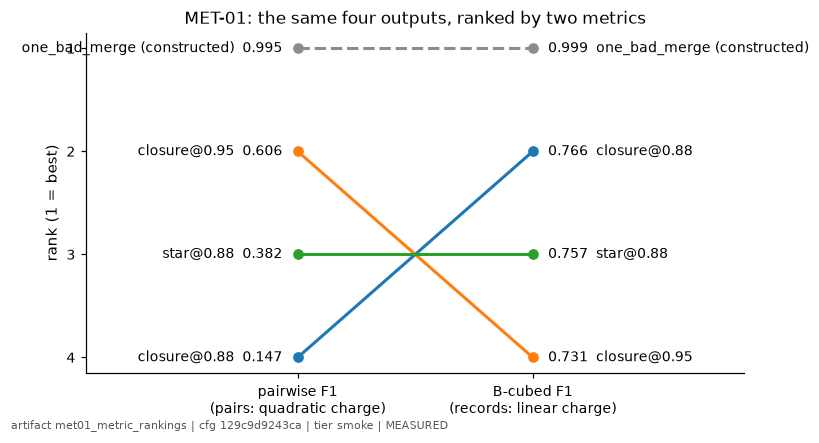

In [11]:
def draw_slopegraph(ax, df, meta):
    sel = df[df["metric"].isin(["pairwise_f1", "bcubed_f1"])]
    val = sel.pivot(index="system", columns="metric", values="value")
    rank = sel.pivot(index="system", columns="metric", values="rank")
    for system in val.index:
        is_con = bool(sel.loc[sel["system"] == system, "constructed"].iloc[0])
        style = {"linestyle": "--", "color": "0.55"} if is_con else {"linestyle": "-"}
        ax.plot([0, 1], [rank.loc[system, "pairwise_f1"], rank.loc[system, "bcubed_f1"]],
                marker="o", linewidth=2, **style)
        label = f"{system} (constructed)" if is_con else system
        ax.annotate(f"{label}  {val.loc[system, 'pairwise_f1']:.3f}",
                    (0, rank.loc[system, "pairwise_f1"]), xytext=(-10, 0),
                    textcoords="offset points", ha="right", va="center", fontsize=9)
        ax.annotate(f"{val.loc[system, 'bcubed_f1']:.3f}  {label}",
                    (1, rank.loc[system, "bcubed_f1"]), xytext=(10, 0),
                    textcoords="offset points", ha="left", va="center", fontsize=9)
    ax.set_xlim(-0.9, 1.9)
    ax.set_xticks([0, 1], ["pairwise F1\n(pairs: quadratic charge)",
                           "B-cubed F1\n(records: linear charge)"])
    ax.set_ylabel("rank (1 = best)")
    ax.set_yticks(sorted(rank["pairwise_f1"].astype(int)))
    ax.invert_yaxis()
    ax.grid(False)


_fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="met01_metric_rankings",
    draw=draw_slopegraph,
    title="MET-01: the same four outputs, ranked by two metrics",
    figsize=(7.5, 4.0),
)

In [12]:
# Score the pre-registered prediction against the computed ranks.
piv_rank = met01.pivot(index="system", columns="metric", values="rank")
real = [s for s in systems if s != CONSTRUCTED]
flips_real = [
    (a, b)
    for i, a in enumerate(real)
    for b in real[i + 1:]
    if (piv_rank.loc[a, "pairwise_f1"] - piv_rank.loc[b, "pairwise_f1"])
    * (piv_rank.loc[a, "bcubed_f1"] - piv_rank.loc[b, "bcubed_f1"]) < 0
]
FIVE = ["pairwise_f1", "bcubed_f1", "vi", "gmd", "cluster_f1"]
rankings = {m: tuple(piv_rank[m].sort_values().index) for m in FIVE}
n_distinct = len(set(rankings.values()))
con = met01[met01["system"] == CONSTRUCTED].set_index("metric")["value"]
outcome = "CONFIRMED" if flips_real and n_distinct >= 2 else "REFUTED"
_ = cards.verdict_box(
    "MET-01",
    outcome=outcome,
    evidence=(
        f"Real-output pairs ranked oppositely by pairwise F1 vs B-cubed F1: {flips_real}. "
        f"The five metrics produce {n_distinct} distinct rankings of the four outputs "
        f"({ {m: ' > '.join(r) for m, r in rankings.items()} }). Constructed one-bad-merge "
        f"scores: B-cubed F1 {con['bcubed_f1']:.4f}, pairwise F1 {con['pairwise_f1']:.4f}, "
        f"GMD {con['gmd']:.0f}. Artifact: met01_metric_rankings (tier {TIER})."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `MET-01`
>
> **Conjecture** Pairwise and entity-level metrics disagree about rankings on realistic ER outputs: pair-counted metrics charge cluster errors quadratically in cluster size while record-averaged metrics charge them linearly, so outputs that differ in error structure (a few large chain merges vs many small splits) trade places between the two views.
>
> **Prediction** Pairwise F1 and B-cubed F1 order at least one pair of the three REAL outputs oppositely (the constructed output is not needed for the flip), and the five metrics produce at least two distinct rankings of the four outputs — there is no metric-free notion of 'who won'.
>
> **Evidence** Real-output pairs ranked oppositely by pairwise F1 vs B-cubed F1: [('closure@0.95', 'closure@0.88'), ('closure@0.95', 'star@0.88'), ('closure@0.88', 'star@0.88')]. The five metrics produce 2 distinct rankings of the four outputs ({'pairwise_f1': 'one_bad_merge > closure@0.95 > star@0.88 > closure@0.88', 'bcubed_f1': 'one_bad_merge > closure@0.88 > star@0.88 > closure@0.95', 'vi': 'one_bad_merge > closure@0.95 > star@0.88 > closure@0.88', 'gmd': 'one_bad_merge > closure@0.88 > star@0.88 > closure@0.95', 'cluster_f1': 'one_bad_merge > closure@0.95 > star@0.88 > closure@0.88'}). Constructed one-bad-merge scores: B-cubed F1 0.9987, pairwise F1 0.9953, GMD 1. Artifact: met01_metric_rankings (tier smoke).


In [13]:
# What did each metric CHARGE for the one constructed merge? Computed, not asserted:
# pairwise counts the cross-pairs of the fused entities (s_a * s_b), B-cubed spreads the
# error over the records touched (s_a + s_b), GMD prices the repair (operations to fix).
s_a, s_b = int(ent_sizes[top2[0]]), int(ent_sizes[top2[1]])
gmd_ops = round(float(con["gmd"]))
merge_charge = pd.DataFrame(
    [
        ("pairwise (cross-pairs charged)", s_a * s_b, "record pairs"),
        ("B-cubed (records touched)", s_a + s_b, "records"),
        ("GMD (repair operations)", gmd_ops, "merge ops"),
    ],
    columns=["metric view", "charge", "unit"],
)
display(merge_charge)
charge_ratio = (s_a * s_b) / max(gmd_ops, 1)
print(f"one merge of entities sized {s_a} and {s_b}: charged {s_a}x{s_b} = {s_a * s_b} "
      f"cross-pairs by the pair view vs {gmd_ops} repair operation(s) by GMD — "
      f"a {charge_ratio:.0f}x ({np.log10(charge_ratio):.1f} orders of magnitude) "
      f"disagreement about the same mistake.")

,metric view,charge,unit
0,pairwise (cross-pairs charged),441,record pairs
1,B-cubed (records touched),42,records
2,GMD (repair operations),1,merge ops


one merge of entities sized 21 and 21: charged 21x21 = 441 cross-pairs by the pair view vs 1 repair operation(s) by GMD — a 441x (2.6 orders of magnitude) disagreement about the same mistake.


### What the constructed output teaches

The one-bad-merge output — truth, except two people fused — ranks near-perfect under
*every* partition metric at this corpus size, but look at what each metric charged for the
identical error (computed in the cell above): GMD counts it as a single repair operation;
B-cubed dilutes it over the ~40 merged records; pairwise F1 charges every cross-pair of
the fused entities — a ~440x disagreement, more than two orders of magnitude, about the
*same mistake* — on a corpus whose largest entities hold a couple dozen records. Scale
those entities up and the
pair-counted charge grows quadratically while the record-averaged charge grows linearly:
at national scale, one hub-glued mega-cluster can dominate an evaluation under one metric
and vanish under another. That asymmetry is why this lab reports **entity-level metrics as
primary and always names the metric** — and why notebook 07 stages the chain-merge
catastrophe as its own experiment.

Note also, from the verdict evidence: the *entity-level* metrics disagree among themselves
(VI and cluster-F side with pairwise F1's ordering here; GMD sides with B-cubed). There is
no "correct" metric hiding behind the disagreement — only declared theories of error cost.
The protocol answer is to pre-register the primary metric family, report the others, and
never let a ranking claim float free of the metric that produced it.

## 4. MET-02 — the operating point is part of the claim

Next question: **holding the metric fixed, can the choice of operating point alone reverse
a comparison?** Most published deltas score each system at its own best-F1 threshold. Hand
& Christen (2018) observed what is wrong with that: F1's implicit precision/recall
weighting depends on each method's own output, so best-F1 scores two systems at two
*different* trade-offs — a comparison between apples and self-selected oranges. The lab's
pre-declared alternatives (PLAN §5):

- **Fixed entity-precision** {0.99, 0.995}: compare recall where precision is pinned.
  With the documented smoke fallback: if a target is unattainable on a small eval set, the
  protocol *reports the highest attainable point and says so* — it never silently switches.
- **Explicit cost grid** {1:1, 1:10, 1:100} FP:FN — pick the threshold minimizing
  `fp_cost*FP + fn_cost*FN` over record pairs; the trade-off is stated, not implicit.
- **Fixed FP-budget per record** (mandatory secondary at scale tiers): a threshold from the
  score tail alone — no truth labels needed, which is what makes it usable at 1e8 where
  truth does not exist. Its mapping to the primary protocol is derived below, once.

The two scorers from section 2 disagree by construction (`jw2` trades precision for
dob-corruption-proof recall), so if best-F1 can crown a different winner than the
pre-declared points, these two should expose it.

In [14]:
_ = cards.conjecture_card(
    card_id="MET-02",
    conjecture=(
        "Per-method best-F1 comparisons are not neutral: because best-F1 lets each scorer "
        "pick its own precision/recall trade-off, the best-F1 winner between jw3 (names+dob "
        "mean Jaro-Winkler) and jw2 (names-only) differs from the winner at pre-declared "
        "operating points that pin the trade-off explicitly."
    ),
    pressure=(
        "No learned pressure — the dial is the comparison protocol: per-method best-F1 vs "
        "fixed B-cubed precision {0.99, 0.995} vs explicit cost grid {1:1, 1:10, 1:100 "
        "FP:FN} vs fixed FP-budget per record, all on the same scored candidate pairs with "
        "transitive-closure clustering."
    ),
    property=(
        "The (threshold, precision, recall) point each protocol selects per scorer — "
        "best-F1 selects different implicit trade-offs for the two scorers, the declared "
        "protocols pin the same trade-off for both."
    ),
    metric=(
        "The jw3-vs-jw2 winner under each protocol: F1 at the per-method optimum; recall at "
        "fixed precision; total cost on the cost grid; recall at matched FP budget."
    ),
    prediction=(
        "The best-F1 winner fails to win at least one pre-declared operating point — "
        "specifically, it does not minimize cost at every ratio in the {1:1, 1:10, 1:100} "
        "grid. At smoke, the 0.99/0.995 precision targets may be unattainable on this eval "
        "set; if so, the fallback rail fires and is reported openly, never silently."
    ),
    registry=registry,
)

### Conjecture card `MET-02`

| | |
|---|---|
| **Conjecture** | Per-method best-F1 comparisons are not neutral: because best-F1 lets each scorer pick its own precision/recall trade-off, the best-F1 winner between jw3 (names+dob mean Jaro-Winkler) and jw2 (names-only) differs from the winner at pre-declared operating points that pin the trade-off explicitly. |
| **Pressure (dial)** | No learned pressure — the dial is the comparison protocol: per-method best-F1 vs fixed B-cubed precision {0.99, 0.995} vs explicit cost grid {1:1, 1:10, 1:100 FP:FN} vs fixed FP-budget per record, all on the same scored candidate pairs with transitive-closure clustering. |
| **Embedding property** | The (threshold, precision, recall) point each protocol selects per scorer — best-F1 selects different implicit trade-offs for the two scorers, the declared protocols pin the same trade-off for both. |
| **System metric** | The jw3-vs-jw2 winner under each protocol: F1 at the per-method optimum; recall at fixed precision; total cost on the cost grid; recall at matched FP budget. |
| **Pre-registered prediction** | The best-F1 winner fails to win at least one pre-declared operating point — specifically, it does not minimize cost at every ratio in the {1:1, 1:10, 1:100} grid. At smoke, the 0.99/0.995 precision targets may be unattainable on this eval set; if so, the fallback rail fires and is reported openly, never silently. |

*Immutable — sha256 `09e8a04f3907`; registered before the affected runs, never edited (PLAN §5).*


The sweep machinery: for each scorer, `find_threshold_for_precision` and
`cost_optimal_threshold` evaluate a transitive-closure clustering at every threshold on a
grid over the scorer's own score values (grid size from the tier table). Every operating
point lands in one long-form frame — curve rows plus operating-point rows — which becomes
the `met02_operating_point_map` artifact.

In [15]:
def make_clusterer(pairs: pd.DataFrame):
    """Transitive-closure clusterer over the full record universe at threshold t."""
    def cluster_at(t: float) -> pd.Series:
        return transitive_closure(pairs, threshold=t, records=records)
    return cluster_at


op_rows: list[dict] = []
curve_frames: list[pd.DataFrame] = []
curves: dict[str, pd.DataFrame] = {}
fp_results: dict[tuple[str, float], dict] = {}


def add_op(scorer: str, protocol: str, threshold: float, precision: float, recall: float,
           f1: float, **extra) -> None:
    op_rows.append({"scorer": scorer, "row_type": "operating_point", "protocol": protocol,
                    "threshold": float(threshold), "precision": float(precision),
                    "recall": float(recall), "f1": float(f1), **extra})

**Fixed precision first.** Watch the `attained` column: on a smoke-sized eval set with
recall-generous blocking, a handful of same-name-same-dob collisions can make 0.99
B-cubed precision unreachable at *any* threshold — the loudly-reported fallback exists for
exactly this case, and the cell below surfaces it rather than burying it.

In [16]:
t0 = time.perf_counter()
for scorer, sc in scored.items():
    spairs = sc.rename(columns={"prob": "score"})
    clusterer = make_clusterer(sc)
    for target in PREC_TARGETS:
        res = find_threshold_for_precision(spairs, clusterer, truth, target=target,
                                           grid=n_grid)
        fp_results[(scorer, target)] = res
        add_op(scorer, f"precision@{target}", res["threshold"], res["attained_precision"],
               res["recall_at"], res["f1_at"], attained=float(res["attained"]),
               fallback=res["fallback"] or "")
        flag = "" if res["attained"] else (
            f"  <-- TARGET UNATTAINABLE on this eval set: fallback="
            f"'{res['fallback']}' (PLAN §5 rail: report, never switch silently)")
        print(f"[{scorer}] precision@{target}: t={res['threshold']:.4f} "
              f"attained P={res['attained_precision']:.4f} R={res['recall_at']:.4f}{flag}")
    curves[scorer] = fp_results[(scorer, PREC_TARGETS[0])]["curve"]
    curve_frames.append(curves[scorer].assign(scorer=scorer, row_type="curve"))
print(f"fixed-precision sweeps: {time.perf_counter() - t0:.1f}s")

[jw3] precision@0.99: t=1.0000 attained P=0.9739 R=0.3649  <-- TARGET UNATTAINABLE on this eval set: fallback='highest_attainable' (PLAN §5 rail: report, never switch silently)


[jw3] precision@0.995: t=1.0000 attained P=0.9739 R=0.3649  <-- TARGET UNATTAINABLE on this eval set: fallback='highest_attainable' (PLAN §5 rail: report, never switch silently)


[jw2] precision@0.99: t=1.0000 attained P=0.9432 R=0.4068  <-- TARGET UNATTAINABLE on this eval set: fallback='highest_attainable' (PLAN §5 rail: report, never switch silently)


[jw2] precision@0.995: t=1.0000 attained P=0.9432 R=0.4068  <-- TARGET UNATTAINABLE on this eval set: fallback='highest_attainable' (PLAN §5 rail: report, never switch silently)
fixed-precision sweeps: 35.2s


**The explicit cost grid.** FP:FN of 1:1, 10:1 and 100:1 — "a false merge costs the same
as / 10x / 100x a missed match," counted over record pairs so chain merges are charged
what they cost. No scorer gets to pick its own trade-off; the trade-off is the protocol.

In [17]:
t0 = time.perf_counter()
for scorer, sc in scored.items():
    spairs = sc.rename(columns={"prob": "score"})
    clusterer = make_clusterer(sc)
    for fp_cost, fn_cost in COST_GRID:
        res = cost_optimal_threshold(spairs, clusterer, truth, fp_cost=fp_cost,
                                     fn_cost=fn_cost, grid=n_grid)
        add_op(scorer, f"cost@{fp_cost}:{fn_cost}", res["threshold"], res["precision"],
               res["recall"], res["f1"], cost=res["cost"], fp=res["fp"], fn=res["fn"])
        print(f"[{scorer}] cost {fp_cost}:{fn_cost} -> t={res['threshold']:.4f} "
              f"cost={res['cost']:,.0f} (FP={res['fp']:,.0f} FN={res['fn']:,.0f}) "
              f"P={res['precision']:.4f} R={res['recall']:.4f}")
print(f"cost-grid sweeps: {time.perf_counter() - t0:.1f}s")

[jw3] cost 1:1 -> t=0.9463 cost=35,160 (FP=14,931 FN=20,229) P=0.9326 R=0.6130


[jw3] cost 10:1 -> t=1.0000 cost=116,431 (FP=8,299 FN=33,441) P=0.9739 R=0.3649


[jw3] cost 100:1 -> t=1.0000 cost=863,341 (FP=8,299 FN=33,441) P=0.9739 R=0.3649


[jw2] cost 1:1 -> t=0.9090 cost=39,315 (FP=21,983 FN=17,332) P=0.9137 R=0.6713


[jw2] cost 10:1 -> t=1.0000 cost=182,194 (FP=15,077 FN=31,424) P=0.9432 R=0.4068


[jw2] cost 100:1 -> t=1.0000 cost=1,539,124 (FP=15,077 FN=31,424) P=0.9432 R=0.4068
cost-grid sweeps: 51.8s


**The FP-budget protocol** needs no truth at all: cap accepted pairs at B per record and
read the threshold off the score tail. Two honest wrinkles it must survive: a cheap
string scorer's distribution is *chunky* (thousands of pairs score exactly 1.0), and the
conservative tie rule — if keeping a tie group would blow the budget, drop the whole
group — can leave a small budget keeping *nothing*. The cell prints `pairs_kept` so the
degenerate budgets are visible, not hidden.

In [18]:
for scorer, sc in scored.items():
    clusterer = make_clusterer(sc)
    for budget in BUDGETS:
        tb = fp_budget_threshold(sc["prob"], budget_per_record=budget, n_records=len(sub))
        kept = int((sc["prob"] >= tb).sum())
        pred = clusterer(tb)
        b3 = bcubed(pred, truth)
        add_op(scorer, f"budget@{budget}", tb, b3["precision"], b3["recall"], b3["f1"],
               budget_per_record=budget, pairs_kept=kept)
        note = "  <-- budget below the score-1.0 tie mass: keeps nothing" if kept == 0 else ""
        print(f"[{scorer}] budget {budget}/record -> t={tb:.4f} pairs_kept={kept:,} "
              f"P={b3['precision']:.4f} R={b3['recall']:.4f}{note}")

[jw3] budget 1.0/record -> t=1.0000 pairs_kept=0 P=1.0000 R=0.1056  <-- budget below the score-1.0 tie mass: keeps nothing


[jw3] budget 2.0/record -> t=0.9800 pairs_kept=15,830 P=0.9734 R=0.4197


[jw3] budget 4.0/record -> t=0.9167 pairs_kept=32,040 P=0.8689 R=0.6994


[jw2] budget 1.0/record -> t=1.0000 pairs_kept=0 P=1.0000 R=0.1056  <-- budget below the score-1.0 tie mass: keeps nothing
[jw2] budget 2.0/record -> t=1.0000 pairs_kept=0 P=1.0000 R=0.1056  <-- budget below the score-1.0 tie mass: keeps nothing


[jw2] budget 4.0/record -> t=0.9250 pairs_kept=32,049 P=0.9230 R=0.6273


**Finally, the banned protocol** — computed here *only* to demonstrate what it does: each
scorer's F1-maximizing threshold from its own sweep curve.

In [19]:
for scorer, curve in curves.items():
    best = curve.sort_values(["f1", "threshold"], ascending=False).iloc[0]
    add_op(scorer, "best_f1", best["threshold"], best["precision"], best["recall"],
           best["f1"])
    print(f"[{scorer}] best-F1 (per-method optimum, banned as a comparison): "
          f"t={best['threshold']:.4f} F1={best['f1']:.4f} "
          f"(P={best['precision']:.4f}, R={best['recall']:.4f})")

[jw3] best-F1 (per-method optimum, banned as a comparison): t=0.9006 F1=0.7827 (P=0.8582, R=0.7195)
[jw2] best-F1 (per-method optimum, banned as a comparison): t=0.8476 F1=0.7959 (P=0.8725, R=0.7317)


In [20]:
met02 = pd.concat([pd.DataFrame(op_rows), *curve_frames], ignore_index=True)
registry.register(
    "met02_operating_point_map",
    met02,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "scorers": {"jw3": "mean JW over given_name/family_name/dob",
                    "jw2": "mean JW over given_name/family_name only"},
        "clustering": "transitive closure over the full record universe",
        "grid": n_grid, "precision_targets": list(PREC_TARGETS),
        "cost_grid_fp_fn": [list(c) for c in COST_GRID], "budgets_per_record": list(BUDGETS),
        "precision_recall_are": "B-cubed (entity-level), per PLAN §5",
        "n_records": len(sub), "n_entities": int(truth.nunique()),
    },
)
display(
    met02[met02["row_type"] == "operating_point"]
    .set_index(["scorer", "protocol"])[
        ["threshold", "precision", "recall", "f1", "cost", "attained", "fallback",
         "pairs_kept"]
    ]
    .round(4)
    .sort_index()
)

threshold  precision  recall      f1       cost  \
scorer protocol                                                           
jw2    best_f1             0.8476     0.8725  0.7317  0.7959        NaN   
       budget@1.0          1.0000     1.0000  0.1056  0.1910        NaN   
       budget@2.0          1.0000     1.0000  0.1056  0.1910        NaN   
       budget@4.0          0.9250     0.9230  0.6273  0.7469        NaN   
       cost@100:1          1.0000     0.9432  0.4068  0.5685  1539124.0   
       cost@10:1           1.0000     0.9432  0.4068  0.5685   182194.0   
       cost@1:1            0.9090     0.9137  0.6713  0.7740    39315.0   
       precision@0.99      1.0000     0.9432  0.4068  0.5685        NaN   
       precision@0.995     1.0000     0.9432  0.4068  0.5685        NaN   
jw3    best_f1             0.9006     0.8582  0.7195  0.7827        NaN   
       budget@1.0          1.0000     1.0000  0.1056  0.1910        NaN   
       budget@2.0          0.9800     0.9734  0.4197  0.5865        NaN   
       budget@4.0          0.9167     0.8689  0.6994  0.7750        NaN   
       cost@100:1          1.0000     0.9739  0.3649  0.5309   863341.0   
       cost@10:1           1.0000     0.9739  0.3649  0.5309   116431.0   
       cost@1:1            0.9463     0.9326  0.6130  0.7397    35160.0   
       precision@0.99      1.0000     0.9739  0.3649  0.5309        NaN   
       precision@0.995     1.0000     0.9739  0.3649  0.5309        NaN   

                        attained            fallback  pairs_kept  
scorer protocol                                                   
jw2    best_f1               NaN                 NaN         NaN  
       budget@1.0            NaN                 NaN         0.0  
       budget@2.0            NaN                 NaN         0.0  
       budget@4.0            NaN                 NaN     32049.0  
       cost@100:1            NaN                 NaN         NaN  
       cost@10:1             NaN                 NaN         NaN  
       cost@1:1              NaN                 NaN         NaN  
       precision@0.99        0.0  highest_attainable         NaN  
       precision@0.995       0.0  highest_attainable         NaN  
jw3    best_f1               NaN                 NaN         NaN  
       budget@1.0            NaN                 NaN         0.0  
       budget@2.0            NaN                 NaN     15830.0  
       budget@4.0            NaN                 NaN     32040.0  
       cost@100:1            NaN                 NaN         NaN  
       cost@10:1             NaN                 NaN         NaN  
       cost@1:1              NaN                 NaN         NaN  
       precision@0.99        0.0  highest_attainable         NaN  
       precision@0.995       0.0  highest_attainable         NaN

### The operating-point map

Each scorer's full precision-recall sweep, with every protocol's chosen point marked. The
two curves cross — which is precisely why the protocols can crown different winners: ask
in the crossing's recall-rich region (best-F1 does) and one scorer wins; pin precision or
price false merges (the lab's protocols) and the other does.

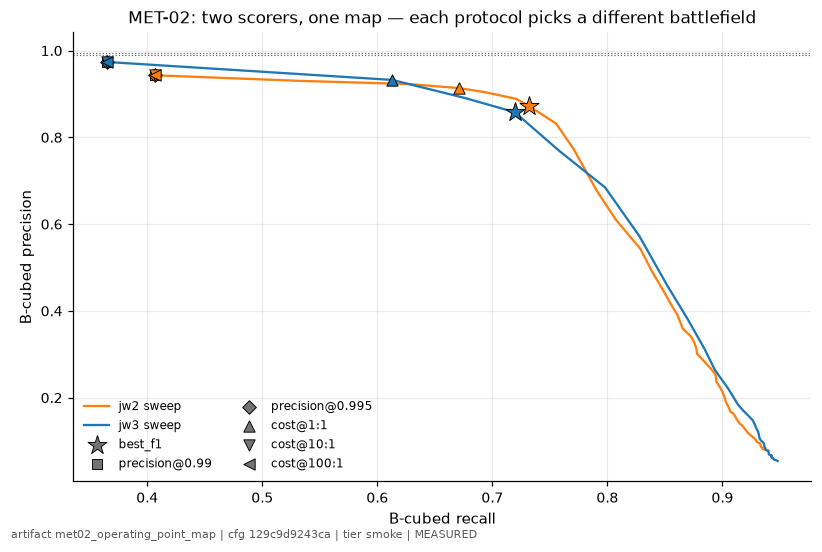

In [21]:
def draw_op_map(ax, df, meta):
    colors = {"jw3": "C0", "jw2": "C1"}
    for scorer, g in df[df["row_type"] == "curve"].groupby("scorer"):
        g = g.sort_values("recall")
        ax.plot(g["recall"], g["precision"], color=colors[scorer], linewidth=1.5,
                label=f"{scorer} sweep")
    marker_of = {"best_f1": ("*", 170), "precision@0.99": ("s", 45),
                 "precision@0.995": ("D", 40), "cost@1:1": ("^", 55), "cost@10:1": ("v", 55),
                 "cost@100:1": ("<", 55)}
    for _, r in df[df["row_type"] == "operating_point"].iterrows():
        if r["protocol"] not in marker_of:
            continue  # budget points overlap the curve tail; the table above carries them
        m, s = marker_of[r["protocol"]]
        ax.scatter(r["recall"], r["precision"], marker=m, s=s, color=colors[r["scorer"]],
                   edgecolor="black", linewidth=0.6, zorder=5)
    for target in PREC_TARGETS:
        ax.axhline(target, linestyle=":", color="0.4", linewidth=0.8)
    for proto, (m, s) in marker_of.items():  # gray legend proxies for the protocol markers
        ax.scatter([], [], marker=m, s=s, color="0.45", edgecolor="black", linewidth=0.6,
                   label=proto)
    ax.legend(loc="lower left", fontsize=8, ncols=2)
    ax.set_xlabel("B-cubed recall")
    ax.set_ylabel("B-cubed precision")


_fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="met02_operating_point_map",
    draw=draw_op_map,
    title="MET-02: two scorers, one map — each protocol picks a different battlefield",
    figsize=(7.5, 5.0),
)

### Who wins under each protocol?

One winner per protocol, computed from the registered rows: best-F1 by F1; fixed
precision by recall *only if* both scorers attain the target (with the fallback active a
ranking is not declared — that is the rail); cost points by total cost; budgets by recall
at the matched budget (no winner when the budget is degenerate or tied).

In [22]:
ops = met02[met02["row_type"] == "operating_point"]


def winner_of(protocol: str) -> str | None:
    g = ops[ops["protocol"] == protocol].set_index("scorer")
    if protocol.startswith("precision@"):
        if g["attained"].min() < 1.0:
            return None  # fallback fired: the protocol reports, it does not rank
        return g["recall"].idxmax()
    if protocol.startswith("cost@"):
        return g["cost"].idxmin()
    if protocol.startswith("budget@"):
        if g["pairs_kept"].min() == 0 or g["recall"].nunique() == 1:
            return None
        return g["recall"].idxmax()
    return g["f1"].idxmax()  # best_f1


winners = {p: winner_of(p) for p in ops["protocol"].unique()}
winners_df = pd.DataFrame(
    {"winner": {p: w if w is not None else "(no ranking declared)"
                for p, w in winners.items()}}
)
display(winners_df)

best_winner = winners["best_f1"]
cost_winners = {p: w for p, w in winners.items() if p.startswith("cost@")}
reversed_points = [p for p, w in winners.items()
                   if w is not None and p != "best_f1" and w != best_winner]
fallback_fired = bool((ops["fallback"].fillna("") != "").any())
outcome = "CONFIRMED" if any(w != best_winner for w in cost_winners.values()) else (
    "UNEXPLAINED" if reversed_points else "REFUTED")
_ = cards.verdict_box(
    "MET-02",
    outcome=outcome,
    evidence=(
        f"best-F1 crowns {best_winner}; cost-grid winners {cost_winners}; all declared "
        f"winners {winners}. Protocols reversing the best-F1 verdict: {reversed_points}. "
        f"Fixed-precision fallback fired: {fallback_fired} (reported per PLAN §5, "
        f"ranking withheld at unattained targets). Artifact: met02_operating_point_map "
        f"(tier {TIER})."
    ),
    registry=registry,
)

,winner
precision@0.99,(no ranking declared)
precision@0.995,(no ranking declared)
cost@1:1,jw3
cost@10:1,jw3
cost@100:1,jw3
budget@1.0,(no ranking declared)
budget@2.0,(no ranking declared)
budget@4.0,jw3
best_f1,jw2


> ### VERDICT: CONFIRMED — card `MET-02`
>
> **Conjecture** Per-method best-F1 comparisons are not neutral: because best-F1 lets each scorer pick its own precision/recall trade-off, the best-F1 winner between jw3 (names+dob mean Jaro-Winkler) and jw2 (names-only) differs from the winner at pre-declared operating points that pin the trade-off explicitly.
>
> **Prediction** The best-F1 winner fails to win at least one pre-declared operating point — specifically, it does not minimize cost at every ratio in the {1:1, 1:10, 1:100} grid. At smoke, the 0.99/0.995 precision targets may be unattainable on this eval set; if so, the fallback rail fires and is reported openly, never silently.
>
> **Evidence** best-F1 crowns jw2; cost-grid winners {'cost@1:1': 'jw3', 'cost@10:1': 'jw3', 'cost@100:1': 'jw3'}; all declared winners {'precision@0.99': None, 'precision@0.995': None, 'cost@1:1': 'jw3', 'cost@10:1': 'jw3', 'cost@100:1': 'jw3', 'budget@1.0': None, 'budget@2.0': None, 'budget@4.0': 'jw3', 'best_f1': 'jw2'}. Protocols reversing the best-F1 verdict: ['cost@1:1', 'cost@10:1', 'cost@100:1', 'budget@4.0']. Fixed-precision fallback fired: True (reported per PLAN §5, ranking withheld at unattained targets). Artifact: met02_operating_point_map (tier smoke).


### Mapping the FP-budget protocol onto the primary one

PLAN §5 makes fixed-FP-budget-per-record the mandatory *secondary* protocol at scale tiers
and asks for its mapping to the primary (fixed-precision / cost) protocol to be derived
once, here. The mapping is the pairing computed below from the registered rows: **a budget
is an implied precision floor.** Each budget B picks its threshold from the score tail
alone (no truth needed — why it survives at 1e8, where the primary protocol's labeled
sweep does not exist); evaluating that threshold against truth, where truth *is* available,
yields the entity-precision the budget de facto enforced. Read each line as "budget B ~
operating the scorer at the precision printed next to it": that is the exchange rate
scale-tier notebooks (SCL-01/02) will use to translate their budget-based operating points
back into this notebook's precision-based vocabulary. Two caveats travel with it: the
exchange rate is *scorer-specific* (the same budget lands the two scorers at different
precisions below), and a budget below the scorer's score-tie mass is degenerate — it buys
nothing at all, as the `pairs_kept` column above showed.

In [23]:
budget_rows = ops[ops["protocol"].str.startswith("budget@")]
for _, r in budget_rows.sort_values(["scorer", "budget_per_record"]).iterrows():
    if r["pairs_kept"] == 0:
        print(f"[{r['scorer']}] budget {r['budget_per_record']}/record: DEGENERATE "
              f"(below the tie mass; keeps nothing — no precision is bought)")
        continue
    cleared = [t for t in PREC_TARGETS if r["precision"] >= t]
    status = (f"clears precision target(s) {cleared}" if cleared
              else "clears neither fixed-precision target")
    print(f"[{r['scorer']}] budget {r['budget_per_record']}/record -> t={r['threshold']:.4f} "
          f"=> implied B-cubed precision {r['precision']:.4f} (R={r['recall']:.4f}) — "
          f"{status}")

[jw2] budget 1.0/record: DEGENERATE (below the tie mass; keeps nothing — no precision is bought)
[jw2] budget 2.0/record: DEGENERATE (below the tie mass; keeps nothing — no precision is bought)
[jw2] budget 4.0/record -> t=0.9250 => implied B-cubed precision 0.9230 (R=0.6273) — clears neither fixed-precision target
[jw3] budget 1.0/record: DEGENERATE (below the tie mass; keeps nothing — no precision is bought)
[jw3] budget 2.0/record -> t=0.9800 => implied B-cubed precision 0.9734 (R=0.4197) — clears neither fixed-precision target
[jw3] budget 4.0/record -> t=0.9167 => implied B-cubed precision 0.8689 (R=0.6994) — clears neither fixed-precision target


## 5. MET-03 — which resampling unit tells the truth about uncertainty?

Last question, and the one that decides whether any interval this lab ever prints can be
believed: **when we bootstrap a confidence interval for an ER metric, what should be
resampled?** ER records are not independent: all records of one person share their fate
(one bad merge wrongs all of them together). Resampling *pairs* (the naive protocol
inherited from classification) or *records* pretends otherwise. The lab expects the
*entity* to be the exchangeable unit — but expectation is not evidence, so we measure
**coverage**: the fraction of repeated experiments in which a nominal-95% interval
actually contains the true value.

Coverage needs a known truth, which no real corpus provides — so this is a **simulation
with the generating process fully in view** (and honestly synthetic: nothing here is
historical_50k data). Each simulated world draws entities i.i.d. (sizes 1 + Poisson, kept
deliberately small so the pair-unit BCa jackknife stays affordable at smoke); a synthetic
"system" then corrupts the truth with entity-level errors — a split with probability 0.35,
and a merge of randomly paired entities with probability 0.30 — so errors are correlated
*within* entities and (through merges) across merged pairs, the dependence structure real
outputs have. The estimand is the population value of each metric, computed once on one
very large draw from the same process; each of the simulated small worlds then gets a BCa
interval per resampling unit, and we count how often it covers.

Both metrics are passed by their `MULTIPLIER_METRICS` names, so entity/record units use
the unbiased frozen-contribution bootstrap and the pair unit uses the rebuilt pair
universe — the estimators `er_lab.eval.bootstrap` documents.

In [24]:
_ = cards.conjecture_card(
    card_id="MET-03",
    conjecture=(
        "The bootstrap resampling unit decides CI honesty for ER metrics: records of one "
        "entity share their fate, so only entity-level resampling reproduces the sampling "
        "variability of entity-structured errors, while record- and pair-level resampling "
        "fake independence and produce intervals that are too narrow (and, for pair "
        "resampling of non-pair-decomposable metrics, mis-centered)."
    ),
    pressure=(
        "No learned pressure — the dial is the bootstrap resampling unit {entity, record, "
        "pair} in a seeded simulation with entity-level split/merge errors (p_split=0.35, "
        "p_merge=0.30, sizes 1+Poisson(2.5)) and a known population metric value."
    ),
    property=(
        "Empirical coverage of nominal-95% BCa intervals for bcubed_f1 and pairwise_f1 "
        "(MULTIPLIER_METRICS names), estimated over independently simulated worlds."
    ),
    metric=(
        "Coverage per (unit, metric) cell, with Monte-Carlo error; the lab's default unit "
        "is chosen as the unit with no under-coverage beyond Monte-Carlo error."
    ),
    prediction=(
        "Entity-unit coverage is approximately nominal — no under-coverage beyond MC error "
        "(>= 0.88 on both metrics; conservative over-coverage tolerated). Pair-unit "
        "under-covers badly (<= 0.80 on both metrics). Record-unit under-covers for at "
        "least one metric (<= 0.88)."
    ),
    registry=registry,
)

### Conjecture card `MET-03`

| | |
|---|---|
| **Conjecture** | The bootstrap resampling unit decides CI honesty for ER metrics: records of one entity share their fate, so only entity-level resampling reproduces the sampling variability of entity-structured errors, while record- and pair-level resampling fake independence and produce intervals that are too narrow (and, for pair resampling of non-pair-decomposable metrics, mis-centered). |
| **Pressure (dial)** | No learned pressure — the dial is the bootstrap resampling unit {entity, record, pair} in a seeded simulation with entity-level split/merge errors (p_split=0.35, p_merge=0.30, sizes 1+Poisson(2.5)) and a known population metric value. |
| **Embedding property** | Empirical coverage of nominal-95% BCa intervals for bcubed_f1 and pairwise_f1 (MULTIPLIER_METRICS names), estimated over independently simulated worlds. |
| **System metric** | Coverage per (unit, metric) cell, with Monte-Carlo error; the lab's default unit is chosen as the unit with no under-coverage beyond Monte-Carlo error. |
| **Pre-registered prediction** | Entity-unit coverage is approximately nominal — no under-coverage beyond MC error (>= 0.88 on both metrics; conservative over-coverage tolerated). Pair-unit under-covers badly (<= 0.80 on both metrics). Record-unit under-covers for at least one metric (<= 0.88). |

*Immutable — sha256 `2267666449ef`; registered before the affected runs, never edited (PLAN §5).*


In [25]:
SIZE_MEAN = 2.5  # entity size = 1 + Poisson(SIZE_MEAN)
P_SPLIT = 0.35  # an entity's records are split into two clusters w.p. P_SPLIT
P_MERGE = 0.30  # a randomly drawn entity pair is fused in pred w.p. P_MERGE


def simulate_world(n_entities: int, rng: np.random.Generator) -> tuple[pd.Series, pd.Series]:
    """One simulated (pred, truth): i.i.d. entities + entity-level split/merge errors."""
    sizes = 1 + rng.poisson(SIZE_MEAN, n_entities)
    rec_ent = np.repeat(np.arange(n_entities), sizes)
    n = len(rec_ent)
    pred = rec_ent.astype(np.int64).copy()
    # splits: each record of a split entity flips a fair coin into a shadow cluster
    split_mask = (sizes >= 2) & (rng.random(n_entities) < P_SPLIT)
    coin = rng.random(n) < 0.5
    pred[split_mask[rec_ent] & coin] += n_entities  # shadow cluster ids
    # merges: random disjoint entity pairs; the two base parts are fused w.p. P_MERGE
    perm = rng.permutation(n_entities)
    relabel = np.arange(2 * n_entities)
    merge_flags = rng.random(n_entities // 2) < P_MERGE
    for k in np.flatnonzero(merge_flags):
        relabel[perm[2 * k + 1]] = relabel[perm[2 * k]]
    idx = pd.Index([f"r{i}" for i in range(n)])
    return pd.Series(relabel[pred], index=idx), pd.Series(rec_ent, index=idx)


COV_METRICS = ("bcubed_f1", "pairwise_f1")
assert all(m in MULTIPLIER_METRICS for m in COV_METRICS)
pred_pop, truth_pop = simulate_world(n_pop, np.random.default_rng([cfg.run.seed, 999]))
pop_value = {"bcubed_f1": bcubed(pred_pop, truth_pop)["f1"],
             "pairwise_f1": pairwise(pred_pop, truth_pop)["f1"]}
print(f"population draw: {truth_pop.nunique():,} entities / {len(truth_pop):,} records")
print("population metric values (the coverage targets): "
      + ", ".join(f"{m}={v:.4f}" for m, v in pop_value.items()))

population draw: 40,000 entities / 139,755 records
population metric values (the coverage targets): bcubed_f1=0.8846, pairwise_f1=0.8039


The grid itself: every simulated world gets a nominal-95% BCa interval per unit and
metric, all from the same seeded draws (the interval, not the world, is what varies across
units). A world where the CI machinery legitimately refuses (its documented NaN rail) is
counted as a failure, not silently dropped — the artifact carries the count.

In [26]:
UNITS = ("entity", "record", "pair")
t0 = time.perf_counter()
cov_rows, sim_points = [], {m: [] for m in COV_METRICS}
for s in range(n_sims):
    pred_s, truth_s = simulate_world(n_sim_entities, np.random.default_rng([cfg.run.seed, s]))
    sim_points["bcubed_f1"].append(bcubed(pred_s, truth_s)["f1"])
    sim_points["pairwise_f1"].append(pairwise(pred_s, truth_s)["f1"])
    for unit in UNITS:
        for metric in COV_METRICS:
            try:
                res = bootstrap_ci(pred_s, truth_s, metric, unit=unit, n_boot=n_boot_cov,
                                   seed=cfg.run.seed * 1000 + s, method="bca")
                cov_rows.append(
                    {"sim": s, "unit": unit, "metric": metric, "failed": False,
                     "covered": bool(res["ci_low"] <= pop_value[metric] <= res["ci_high"]),
                     "width": res["ci_high"] - res["ci_low"], "point": res["point"]})
            except ValueError:  # the documented NaN rail refused this world
                cov_rows.append({"sim": s, "unit": unit, "metric": metric, "failed": True,
                                 "covered": None, "width": np.nan, "point": np.nan})
cov = pd.DataFrame(cov_rows)
print(f"{n_sims} worlds x {len(UNITS)} units x {len(COV_METRICS)} metrics "
      f"in {time.perf_counter() - t0:.1f}s")
for m in COV_METRICS:
    print(f"  honesty check — mean simulated point estimate {m}: "
          f"{np.mean(sim_points[m]):.4f} vs population {pop_value[m]:.4f}")

120 worlds x 3 units x 2 metrics in 64.0s
  honesty check — mean simulated point estimate bcubed_f1: 0.8862 vs population 0.8846
  honesty check — mean simulated point estimate pairwise_f1: 0.8083 vs population 0.8039


In [27]:
ok = cov[~cov["failed"]]
met03 = (
    ok.groupby(["unit", "metric"])
    .agg(coverage=("covered", "mean"), mean_width=("width", "mean"),
         mean_point=("point", "mean"), n_sims_effective=("covered", "size"))
    .reset_index()
)
met03["n_failed"] = [
    int(cov[(cov["unit"] == u) & (cov["metric"] == m) & cov["failed"]].shape[0])
    for u, m in zip(met03["unit"], met03["metric"])
]
se = np.sqrt(met03["coverage"] * (1 - met03["coverage"]) / met03["n_sims_effective"])
met03["mc_lo"] = (met03["coverage"] - 1.96 * se).clip(lower=0.0)
met03["mc_hi"] = (met03["coverage"] + 1.96 * se).clip(upper=1.0)
met03["pop_value"] = met03["metric"].map(pop_value)
met03["nominal"] = NOMINAL
registry.register(
    "met03_bootstrap_coverage",
    met03,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "design": {"n_sims": n_sims, "n_entities_per_sim": n_sim_entities,
                   "n_boot": n_boot_cov, "method": "bca", "alpha": 0.05,
                   "population_entities": n_pop},
        "dgp": {"size": f"1+Poisson({SIZE_MEAN})", "p_split": P_SPLIT, "p_merge": P_MERGE,
                "note": "synthetic worlds — deliberately NOT corpus data; truth is known "
                        "by construction so coverage is checkable"},
        "metrics": list(COV_METRICS),
        "mc_band": "normal-approx 95% Monte-Carlo interval on the coverage proportion",
    },
)
display(met03.set_index(["unit", "metric"]).round(4))

coverage  mean_width  mean_point  n_sims_effective  \
unit   metric                                                            
entity bcubed_f1      0.9000      0.0703      0.8862               120   
       pairwise_f1    0.9917      0.2394      0.8083               120   
pair   bcubed_f1      0.0417      0.0224      0.9195               120   
       pairwise_f1    0.6250      0.0629      0.8083               120   
record bcubed_f1      0.7000      0.0381      0.8862               120   
       pairwise_f1    0.9333      0.1429      0.8083               120   

                    n_failed   mc_lo   mc_hi  pop_value  nominal  
unit   metric                                                     
entity bcubed_f1           0  0.8463  0.9537     0.8846     0.95  
       pairwise_f1         0  0.9754  1.0000     0.8039     0.95  
pair   bcubed_f1           0  0.0059  0.0774     0.8846     0.95  
       pairwise_f1         0  0.5384  0.7116     0.8039     0.95  
record bcubed_f1           0  0.6180  0.7820     0.8846     0.95  
       pairwise_f1         0  0.8887  0.9780     0.8039     0.95

### Coverage, pictured

A nominal-95% interval should cover ~95% of the time — the dotted line. Bars ending far
below it are intervals that are too narrow (or mis-centered): they would let the lab
declare significant differences that are noise. Note also `mean_point` vs `pop_value` in
the table above for the pair unit on B-cubed: the pair-universe estimate is not even
centered on the right quantity — the pair bootstrap answers a different question than the
partition metric asks.

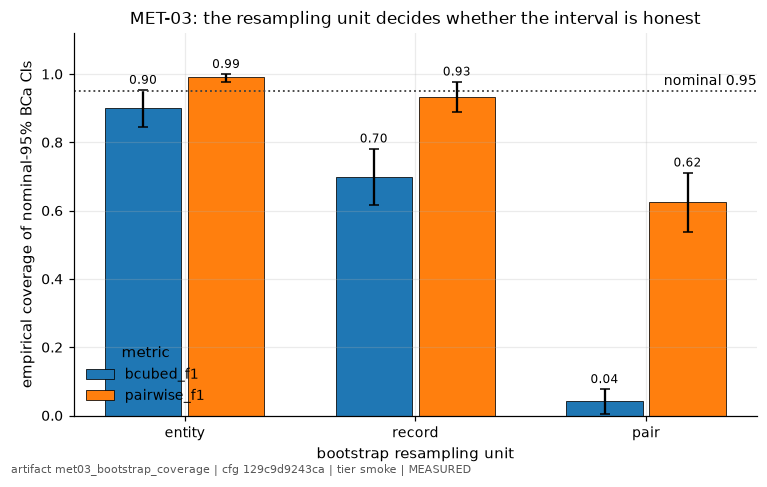

In [28]:
def draw_coverage(ax, df, meta):
    units = ["entity", "record", "pair"]
    metrics = list(dict.fromkeys(df["metric"]))
    width = 0.36
    xs = np.arange(len(units))
    for j, metric in enumerate(metrics):
        g = df[df["metric"] == metric].set_index("unit").reindex(units)
        pos = xs + (j - (len(metrics) - 1) / 2) * width
        err = np.vstack([g["coverage"] - g["mc_lo"], g["mc_hi"] - g["coverage"]])
        bars = ax.bar(pos, g["coverage"], width=width * 0.92, label=metric,
                      yerr=err, capsize=3, linewidth=0.5, edgecolor="black")
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
    nominal = float(df["nominal"].iloc[0])
    ax.axhline(nominal, linestyle=":", color="0.25", linewidth=1.2)
    ax.annotate(f"nominal {nominal:.2f}", (len(units) - 0.52, nominal),
                xytext=(0, 4), textcoords="offset points", ha="right", fontsize=9)
    ax.set_xticks(xs, units)
    ax.set_xlabel("bootstrap resampling unit")
    ax.set_ylabel("empirical coverage of nominal-95% BCa CIs")
    ax.set_ylim(0, 1.12)
    ax.legend(title="metric", loc="lower left")


_fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="met03_bootstrap_coverage",
    draw=draw_coverage,
    title="MET-03: the resampling unit decides whether the interval is honest",
    figsize=(7.0, 4.4),
)

In [29]:
covg = met03.set_index(["unit", "metric"])["coverage"]
checks = {
    "entity >= 0.88 on both metrics": bool((covg["entity"] >= 0.88).all()),
    "pair <= 0.80 on both metrics": bool((covg["pair"] <= 0.80).all()),
    "record <= 0.88 on >= 1 metric": bool((covg["record"] <= 0.88).any()),
}
outcome = "CONFIRMED" if all(checks.values()) else "REFUTED"
worst = {u: float(covg[u].min()) for u in UNITS}
pair_b3_point = float(
    met03.set_index(["unit", "metric"]).loc[("pair", "bcubed_f1"), "mean_point"]
)
_ = cards.verdict_box(
    "MET-03",
    outcome=outcome,
    evidence=(
        f"Coverage of nominal-95% BCa CIs over {n_sims} simulated worlds "
        f"({n_sim_entities} entities each): "
        + "; ".join(f"{u}/{m}={covg[(u, m)]:.3f}" for u in UNITS for m in COV_METRICS)
        + f". Checks: {checks}. Worst-case coverage per unit: {worst}. Pair-unit B-cubed "
        f"mean point estimate {pair_b3_point:.4f} vs population "
        f"{pop_value['bcubed_f1']:.4f} (mis-centered). "
        f"Artifact: met03_bootstrap_coverage (tier {TIER})."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `MET-03`
>
> **Conjecture** The bootstrap resampling unit decides CI honesty for ER metrics: records of one entity share their fate, so only entity-level resampling reproduces the sampling variability of entity-structured errors, while record- and pair-level resampling fake independence and produce intervals that are too narrow (and, for pair resampling of non-pair-decomposable metrics, mis-centered).
>
> **Prediction** Entity-unit coverage is approximately nominal — no under-coverage beyond MC error (>= 0.88 on both metrics; conservative over-coverage tolerated). Pair-unit under-covers badly (<= 0.80 on both metrics). Record-unit under-covers for at least one metric (<= 0.88).
>
> **Evidence** Coverage of nominal-95% BCa CIs over 120 simulated worlds (60 entities each): entity/bcubed_f1=0.900; entity/pairwise_f1=0.992; record/bcubed_f1=0.700; record/pairwise_f1=0.933; pair/bcubed_f1=0.042; pair/pairwise_f1=0.625. Checks: {'entity >= 0.88 on both metrics': True, 'pair <= 0.80 on both metrics': True, 'record <= 0.88 on >= 1 metric': True}. Worst-case coverage per unit: {'entity': 0.9, 'record': 0.7, 'pair': 0.041666666666666664}. Pair-unit B-cubed mean point estimate 0.9195 vs population 0.8846 (mis-centered). Artifact: met03_bootstrap_coverage (tier smoke).


In [30]:
# The default-unit decision, computed from the registered numbers (not asserted).
worst_by_unit = covg.groupby("unit").min().sort_values(ascending=False)
default_unit = worst_by_unit.index[0]
print("worst-case coverage per unit (higher is better, decision rule = no under-coverage "
      "beyond MC error):")
for u, v in worst_by_unit.items():
    print(f"  {u:>7}: {v:.3f}")
print(f"\n=> the lab's default bootstrap unit going forward: '{default_unit}'")

worst-case coverage per unit (higher is better, decision rule = no under-coverage beyond MC error):
   entity: 0.900
   record: 0.700
     pair: 0.042

=> the lab's default bootstrap unit going forward: 'entity'


**The default unit, per these numbers.** Entity resampling is the only unit whose
coverage is consistent with nominal on both metrics in this design — its B-cubed coverage
sits slightly below 0.95 (within Monte-Carlo reach at this simulation count, a
small-sample BCa effect worth re-checking in MET-04's larger variance study) and its
pairwise coverage runs conservative, which is the tolerable direction of error. Record
resampling under-covers B-cubed F1 badly — it fakes independence *within* entities, which
is exactly where ER errors are correlated. Pair resampling is the disaster the literature
walks into by default: far-below-nominal coverage on both metrics and, for B-cubed, a
point estimate that is not even centered on the population value. Where dependence is
wider than the entity (households, blocks), the same machinery offers a `block` unit —
notebook 05's split construction and MET-07 pick that thread up. **Every headline CI in
this lab from here on resamples entities** (BCa, via `MULTIPLIER_METRICS` names for the
unbiased multiplier path), unless a notebook explicitly argues a wider unit.

## 6. The protocol, assembled once

The three verdicts above compose into one working protocol. As a closing demonstration —
and a template for every comparison the series will make — here is the jw3-vs-jw2 question
answered *properly*: at each scorer's fixed-precision operating point (fallback openly in
force at this tier where it fired), the entity-unit BCa **paired delta** on shared
resample draws for B-cubed recall and precision. Note what honest machinery does to a
smoke-sized comparison: the deltas come with intervals, and only sign-stable intervals
(CI excluding zero) may be read as a difference at all. One caveat travels with this demo:
thresholds were selected on the same records the delta is evaluated on — fine for a
metrology demonstration, but real comparisons in this lab select operating points on
training-side data under MET-07's split rules.

In [31]:
op_preds = {
    scorer: make_clusterer(scored[scorer])(fp_results[(scorer, PREC_TARGETS[0])]["threshold"])
    for scorer in scored
}
for metric in ("bcubed_recall", "bcubed_precision"):
    res = paired_delta(op_preds["jw3"], op_preds["jw2"], truth, metric, unit="entity",
                       n_boot=n_boot_delta, seed=cfg.run.seed)
    verdict = ("sign-stable difference" if res["sign_stable"]
               else "NOT sign-stable — no difference may be claimed")
    print(f"delta {metric} (jw3 - jw2, each at its precision@{PREC_TARGETS[0]} point): "
          f"{res['delta']:+.4f}  95% BCa [{res['ci_low']:+.4f}, {res['ci_high']:+.4f}] "
          f"-> {verdict}")
print("\n(The two scorers occupy genuinely different operating points: at these thresholds "
      "one buys precision, the other recall — the map above showed why no single 'winner' "
      "claim survives without naming the protocol.)")

delta bcubed_recall (jw3 - jw2, each at its precision@0.99 point): -0.0419  95% BCa [-0.0476, -0.0364] -> sign-stable difference
delta bcubed_precision (jw3 - jw2, each at its precision@0.99 point): +0.0307  95% BCa [+0.0219, +0.0404] -> sign-stable difference

(The two scorers occupy genuinely different operating points: at these thresholds one buys precision, the other recall — the map above showed why no single 'winner' claim survives without naming the protocol.)


> ### The protocol box — how this lab tells who won
>
> Every comparison in notebooks 03-18 obeys these rules; each rule cites the registered
> evidence that justifies it.
>
> 1. **Metrics are named, entity-level metrics are primary.** B-cubed P/R/F1, GMD, VI and
>    cluster-F are reported with pairwise P/R secondary — and no ranking claim is ever
>    stated without its metric, because metrics genuinely disagree on rankings
>    (`met01_metric_rankings`). Constructed diagnostic outputs are always labeled as
>    constructed.
> 2. **Operating points are pre-declared, never per-method best-F1.** Fixed entity
>    precision {0.99, 0.995} plus the explicit cost grid {1:1, 1:10, 1:100} FP:FN are the
>    lab-wide primary; fixed FP-budget-per-record is the mandatory secondary at scale
>    tiers, with its budget-to-precision mapping derived in `met02_operating_point_map`.
>    Best-F1 comparisons are banned because they reverse rankings against every declared
>    protocol (`met02_operating_point_map`).
> 3. **Unattainable targets fall back loudly.** When a fixed-precision target cannot be
>    met on an eval set, the highest attainable point is reported *with the fallback
>    flagged* — the protocol is never switched silently (demonstrated live in section 4).
> 4. **Uncertainty resamples entities.** Nominal-95% BCa intervals with the entity as the
>    resampling unit and `MULTIPLIER_METRICS` names for the unbiased multiplier path;
>    record- and pair-unit intervals under-cover (`met03_bootstrap_coverage`). Block-unit
>    resampling is reserved for dependence wider than the entity (MET-07).
> 5. **Comparisons are paired.** Competing systems are evaluated on shared resample draws
>    (`paired_delta`), and only sign-stable intervals may be read as differences.
> 6. **What remains open goes to MET-04** (notebook 09): how many seeds and noise draws
>    each comparison needs — the power table that makes "no difference detected"
>    meaningful too.

## What we now know

- **The metric is part of the claim.** On four outputs built in this run, pairwise F1 and
  B-cubed F1 rank real system pairs in opposite orders, and the five-metric zoo does not
  agree on a single ordering — even among entity-level metrics
  (`met01_metric_rankings`, verdict on card MET-01). The constructed one-bad-merge output
  showed why: the same error is charged quadratically (pairs), linearly (records), or as
  one operation (GMD).
- **The operating point is part of the claim.** The per-method best-F1 comparison crowns a
  different winner than the explicit cost grid on the same scored pairs; the fixed
  0.99/0.995 precision targets were unattainable on this smoke eval set and the fallback
  rail fired openly, exactly as designed (`met02_operating_point_map`, card MET-02). The
  FP-budget protocol maps onto the primary one as a scorer-specific implied precision
  floor — with a documented degenerate regime below the score-tie mass.
- **The resampling unit is part of the claim.** In seeded simulations with known truth,
  entity-unit BCa intervals are the only ones that do not under-cover; record-unit
  intervals under-cover B-cubed F1 and pair-unit intervals fail catastrophically, with the
  pair path mis-centered for B-cubed (`met03_bootstrap_coverage`, card MET-03). The lab's
  default unit is the entity.

## What this changes downstream

- Every later notebook inherits the protocol box above verbatim: named entity-level
  metrics, pre-declared operating points with the loud fallback, entity-unit BCa
  intervals, paired deltas on shared draws.
- Notebook 06 (BAS-01) scores the Fellegi-Sunter baseline at these operating points;
  notebook 07 scales MET-01's one-bad-merge lesson into the chain-merge catastrophe;
  notebook 09 (MET-04) sizes seeds and noise draws on top of this CI machinery; the scale
  notebooks (12, 15) run on the FP-budget secondary protocol via the mapping derived here.
- The three registered artifacts are the citation targets: a protocol rule in a later
  notebook is a pointer to `met01_metric_rankings`, `met02_operating_point_map`, or
  `met03_bootstrap_coverage`, never a bare assertion.

**Artifacts registered by this notebook** (exact names): `met01_metric_rankings`,
`met02_operating_point_map`, `met03_bootstrap_coverage` — plus the immutable conjecture
cards `card_MET-01`, `card_MET-02`, `card_MET-03`.

In [32]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s (tier={TIER})")

notebook wall-clock: 158s (tier=smoke)
